In [1]:
import sys
if "vision_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

环境配置正常


In [2]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import cv2

print("opencv:", cv2.__version__)
print("numpy:", np.__version__)

opencv: 4.13.0
numpy: 2.2.5


<font color = #000000 >

## 8. 直方图与傅里叶变换
</font>


In [3]:
picture = '../Pictures/'
# 定义图像展示函数
def img_show(img):
    if img is None:
        print("图像读取失败")
    else:
        # 图像展示
        cv2.imshow("image", img)    # 首先需要确定图像存在才能打开
        print("img.shape = " , img.shape)
        cv2.waitKey(0)  # 等待时间,0对应无限等待,知道按下任意按键
        cv2.destroyAllWindows() 

<font color = #000000>

### 8-1 直方图定义
+ 其实就是gray图的0-255出现的频率直方图

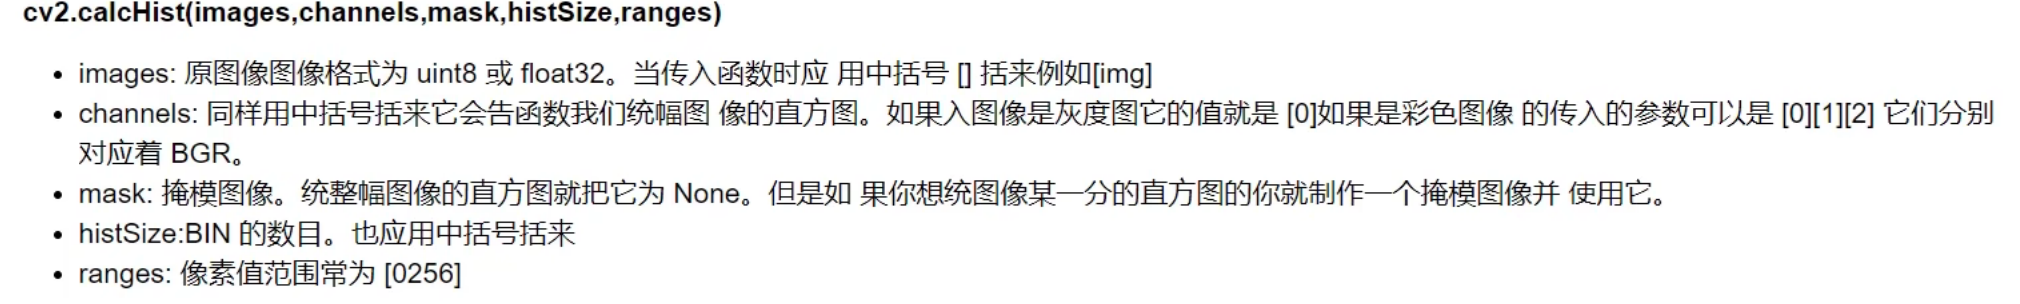


</font>

(256, 1)


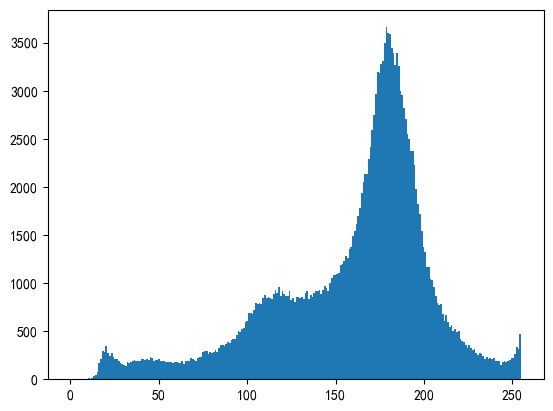

In [4]:
# 灰度图直方图展示
# 读取,必须是灰度图!
img = cv2.imread(picture + 'cat.jpg' , cv2.IMREAD_GRAYSCALE)    # 这里转成了灰度图(灰度图都是uint8)
hist = cv2.calcHist([img] , [0] , None , [256] , [0,256])
print(hist.shape)
# 绘图
plt.hist(img.ravel(), 256)  # ravel() = 把图像矩阵所有像素铺平成一条数组
plt.show()

0 b
1 g
2 r


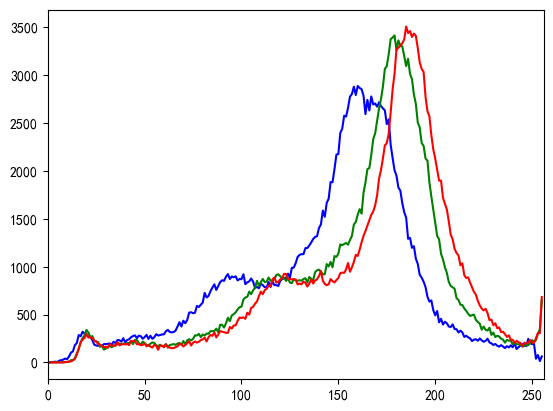

In [5]:
# RGB直方图展示
img = cv2.imread(picture + 'cat.jpg')    # 这里是BGR图像
# 定义颜色
color = ['b' , 'g' , 'r']
# 打印
for i , col in enumerate(color):
    print(i , col)
    histr = cv2.calcHist([img] , [i] , None , [256] , [0,256])
    plt.plot(histr , color = col)
    plt.xlim([0,256])


<font color = #000000>

### 8-2 均衡化原理



</font>

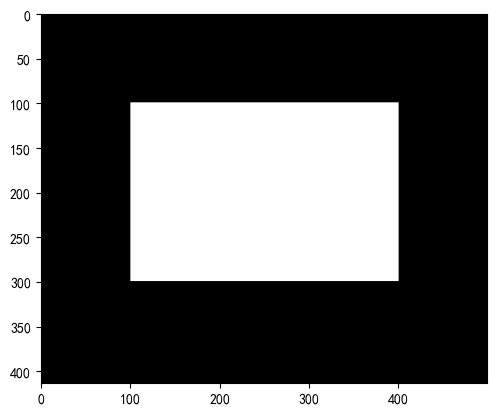

In [6]:
# 图像读取
img = cv2.imread(picture + 'cat.jpg' , cv2.IMREAD_GRAYSCALE)
# 掩码创建
mask = np.zeros(img.shape , np.uint8)
# 掩码需要保存的部分置255,不需要的置0
mask[100:300 , 100:400] = 255 
plt.imshow(mask , 'gray')

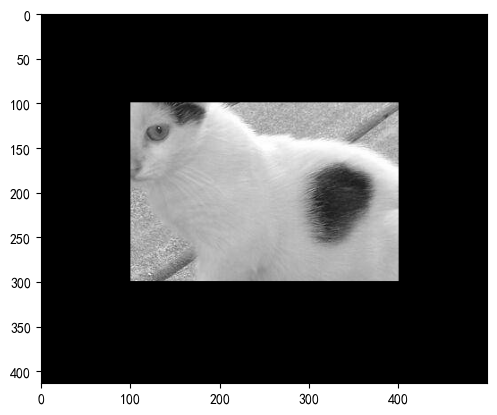

In [7]:
# 进行掩码截图
mask_img = cv2.bitwise_and(img , img , mask=mask) # 与操作
plt.imshow(mask_img , 'gray')

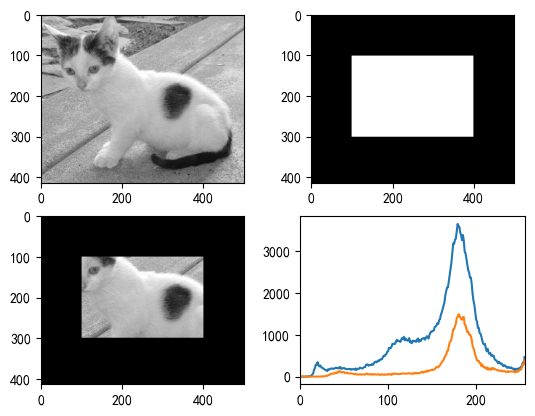

In [8]:
# 展示带掩码和不带掩码的区别展示
hist_none = cv2.calcHist([img] , [0] , None , [256] , [0,256])
hist_mask = cv2.calcHist([img] , [0] , mask , [256] , [0,256])

plt.subplot(221) , plt.imshow(img , 'gray')
plt.subplot(222) , plt.imshow(mask , 'gray')
plt.subplot(223) , plt.imshow(mask_img , 'gray')
plt.subplot(224) , plt.plot(hist_none) , plt.plot(hist_mask)
plt.xlim([0,256])
plt.show()

<font color = #000000>

### 8-3 直方图均衡化



</font>

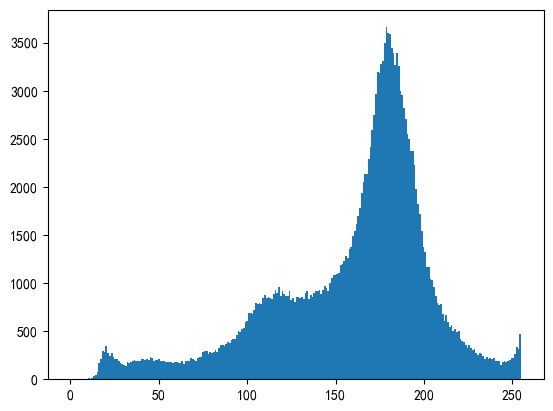

In [10]:
# 读取
img = cv2.imread(picture + 'cat.jpg' , 0)
# 展示直方图
plt.hist(img.ravel() , 256)
plt.show()

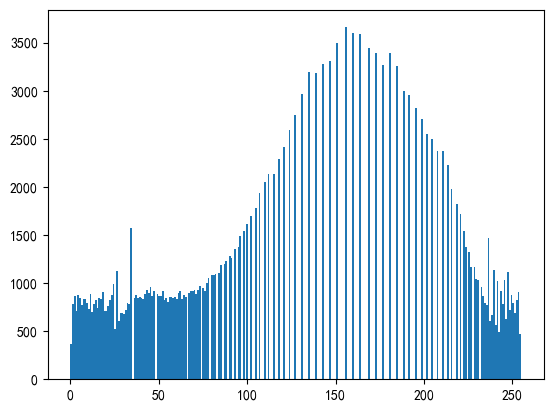

In [14]:
# 均衡化
equ = cv2.equalizeHist(img)
plt.hist(equ.ravel() , 256)
plt.show()

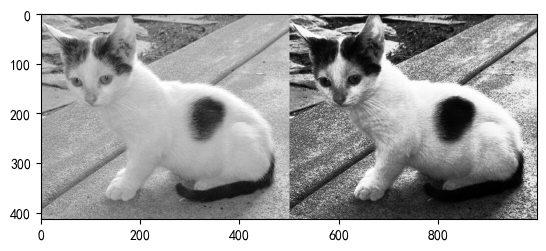

In [ ]:
# 进行对比,均衡化图更加鲜明
res = np.hstack((img , equ))
plt.imshow(res , 'gray')

<font color = #000000>

### 8-4 自适应直方图均衡化: createCLAHE

+ 分块均衡化,防止相互影响


</font>

img.shape =  (341, 1341)


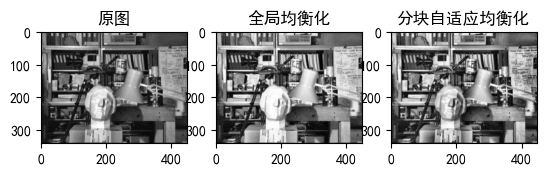

In [ ]:
# 图像读取
img = cv2.imread(picture + 'clahe.jpg' , cv2.IMREAD_GRAYSCALE)
# 全局均衡化
equ = cv2.equalizeHist(img)
# 分块自适应均衡化
clahe = cv2.createCLAHE(clipLimit=2.0 , tileGridSize=(8,8))
res_clahe = clahe.apply(img)
# 对比
plt.subplot(131), plt.imshow(img , 'gray') , plt.title('原图')
plt.subplot(132), plt.imshow(equ , 'gray') , plt.title('全局均衡化')
plt.subplot(133), plt.imshow(res_clahe , 'gray') , plt.title('分块自适应均衡化')

# 放大对比
res = np.hstack((img , equ , res_clahe))
img_show(res)